# Pattern Detection – Day 9: Evaluation

**Student Name:** Traver Dinten
**Country:** Switzerland
**Semester term:** FS26

## Evaluation Approach Definition

The selected metric is **Edge Pixel Density (EPD)**, defined as the fraction of pixels classified as edges relative to the total number of pixels in the image:

$$\text{EPD} = \frac{\text{number of edge pixels}}{\text{total pixels}}$$

EPD quantifies the detection sensitivity of the edge detector configuration: higher EPD indicates more detected edges (potentially including noise), lower EPD indicates more selective detection. This metric is specifically chosen because the problem statement requires balancing detection sensitivity against noise rejection — EPD directly reflects how aggressively a configuration responds to intensity gradients in the Sentinel-2 satellite image. The metric is meaningful when evaluating configurations applied to the same image, allowing relative comparison of detection behavior across parameter settings.

## Setup and Data Loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join("..", "helpers"))

import numpy as np
import cv2
import matplotlib.pyplot as plt
from gee_utils import load_image

DATA_DIR = os.path.join("..", "data", "raw")
FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

IMAGE_PATH = os.path.join(DATA_DIR, "aletsch_tongue_s2.tif")
img_rgb = load_image(IMAGE_PATH)
print(f"Image shape: {img_rgb.shape}")

Image shape: (669, 892, 3)


In [2]:
SIGMA_VALUES = [0.5, 1.0, 2.0, 4.0]
THRESHOLD_PAIRS = [(30, 90), (50, 150), (80, 200), (100, 250)]

gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
total_pixels = gray.shape[0] * gray.shape[1]

def compute_epd(edges):
    return np.count_nonzero(edges) / total_pixels

## Evaluation: Blur Sweep

In [3]:
blur_epd = {}
for sigma in SIGMA_VALUES:
    ksize = int(6 * sigma + 1)
    if ksize % 2 == 0:
        ksize += 1
    blurred = cv2.GaussianBlur(gray, (ksize, ksize), sigmaX=sigma)
    edges = cv2.Canny(blurred, 50, 150)
    blur_epd[sigma] = compute_epd(edges)

baseline_epd_blur = blur_epd[1.0]

print("Blur Sweep – EPD Evaluation (thresholds: 50/150) – Sentinel-2")
print("-" * 55)
print(f"{'Configuration':<25} {'EPD':>10} {'Δ Baseline (%)':>16}")
print("-" * 55)
for sigma, epd in blur_epd.items():
    label = "Baseline (σ=1.0)" if sigma == 1.0 else f"σ={sigma}"
    rel_change = ((epd - baseline_epd_blur) / baseline_epd_blur) * 100
    print(f"{label:<25} {epd:>10.4f} {rel_change:>15.1f}%")

Blur Sweep – EPD Evaluation (thresholds: 50/150) – Sentinel-2
-------------------------------------------------------
Configuration                    EPD   Δ Baseline (%)
-------------------------------------------------------
σ=0.5                         0.0110           321.0%
Baseline (σ=1.0)              0.0026             0.0%
σ=2.0                         0.0000          -100.0%
σ=4.0                         0.0000          -100.0%


## Evaluation: Threshold Sweep

In [4]:
threshold_epd = {}
blurred_baseline = cv2.GaussianBlur(gray, (0, 0), sigmaX=1.0)

for t_low, t_high in THRESHOLD_PAIRS:
    edges = cv2.Canny(blurred_baseline, t_low, t_high)
    threshold_epd[(t_low, t_high)] = compute_epd(edges)

baseline_epd_thresh = threshold_epd[(50, 150)]

print("Threshold Sweep – EPD Evaluation (σ=1.0) – Sentinel-2")
print("-" * 55)
print(f"{'Configuration':<25} {'EPD':>10} {'Δ Baseline (%)':>16}")
print("-" * 55)
for (t_low, t_high), epd in threshold_epd.items():
    label = "Baseline (50/150)" if (t_low, t_high) == (50, 150) else f"({t_low}/{t_high})"
    rel_change = ((epd - baseline_epd_thresh) / baseline_epd_thresh) * 100
    print(f"{label:<25} {epd:>10.4f} {rel_change:>15.1f}%")

Threshold Sweep – EPD Evaluation (σ=1.0) – Sentinel-2
-------------------------------------------------------
Configuration                    EPD   Δ Baseline (%)
-------------------------------------------------------
(30/90)                       0.0160           515.6%
Baseline (50/150)             0.0026             0.0%
(80/200)                      0.0000          -100.0%
(100/250)                     0.0000          -100.0%


## Comparative Visualization

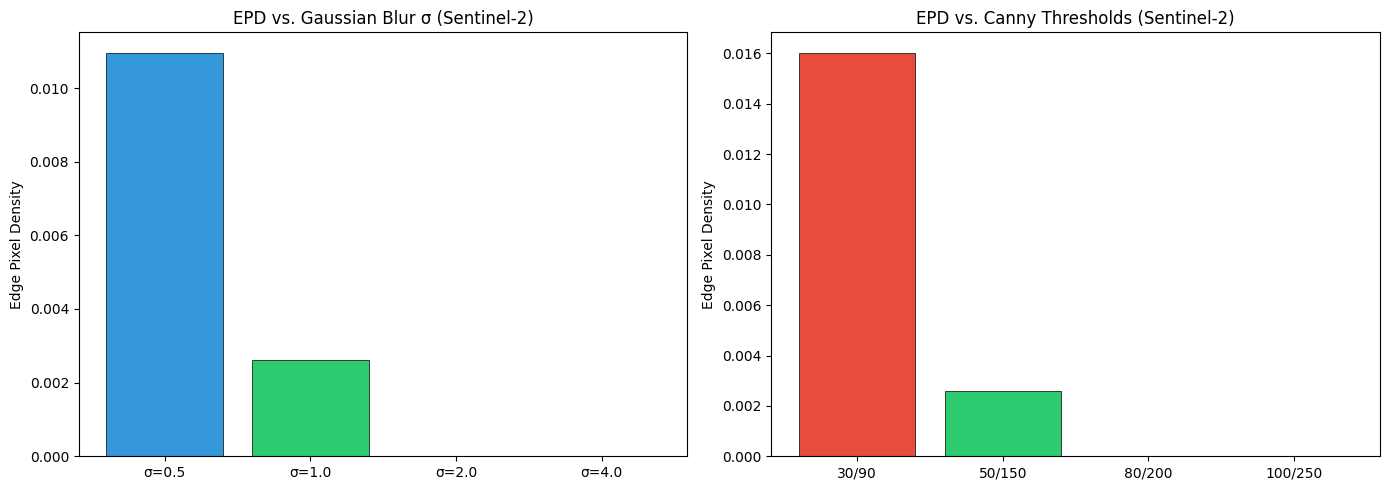

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sigmas = list(blur_epd.keys())
epd_blur = list(blur_epd.values())
colors_b = ["#2ecc71" if s == 1.0 else "#3498db" for s in sigmas]
axes[0].bar([f"σ={s}" for s in sigmas], epd_blur, color=colors_b, edgecolor="black", linewidth=0.5)
axes[0].set_ylabel("Edge Pixel Density")
axes[0].set_title("EPD vs. Gaussian Blur σ (Sentinel-2)")

thresholds = list(threshold_epd.keys())
epd_thresh = list(threshold_epd.values())
colors_t = ["#2ecc71" if t == (50, 150) else "#e74c3c" for t in thresholds]
labels_t = [f"{t[0]}/{t[1]}" for t in thresholds]
axes[1].bar(labels_t, epd_thresh, color=colors_t, edgecolor="black", linewidth=0.5)
axes[1].set_ylabel("Edge Pixel Density")
axes[1].set_title("EPD vs. Canny Thresholds (Sentinel-2)")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day09_epd_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()